<div style="text-align: center;">
  <h1>Fraud Detection Using Machine Learning</h1>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
print(df.duplicated().sum())

1081


In [9]:
df = df.drop_duplicates(subset = df.columns ,keep = 'first')

In [10]:
print(df.duplicated().sum())

0


In [11]:
df['Class'].value_counts(normalize = True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [12]:
df.iloc[:, :20].describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000603,0.000252,0.001043,0.001162,0.000170,0.001515,-0.000264
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,1.076407,1.018720,0.994674,0.995430,0.952215,0.914894,0.873696,0.842507,0.837378,0.813379
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,-4.797473,-18.683715,-5.791881,-19.214325,-4.498945,-14.129855,-25.162799,-9.498746,-7.213527
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.647862,-0.425732,-0.581452,-0.466860,-0.483928,-0.498014,-0.456289
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,-0.012927,0.050209,0.049299,0.067119,-0.065867,-0.002142,0.003367
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.663178,0.492336,0.650104,0.523512,0.398972,0.501956,0.458508
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315112,9.253526,5.041069,5.591971


In [13]:
df.iloc[:, 20:].describe()

,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,0.769984,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,-54.497720,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,39.420904,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [14]:
df['Time'] = df['Time']/3600
df['Time'].describe()

count    283726.000000
mean         26.336410
std          13.189180
min           0.000000
25%          15.056875
50%          23.525694
75%          38.693889
max          47.997778
Name: Time, dtype: float64

In [15]:
df.var().sort_values(ascending=False)

Amount    62699.878108
Time        173.954468
V1            3.794806
V2            2.711631
V3            2.276121
V4            1.999916
V5            1.896152
V6            1.774039
V7            1.507159
V8            1.390169
V9            1.200104
V10           1.158653
V11           1.037791
V13           0.990880
V12           0.989377
V14           0.906714
V15           0.837030
V16           0.763345
V17           0.709819
V18           0.701201
V19           0.661585
V20           0.592876
V22           0.524973
V21           0.524045
V23           0.389005
V24           0.366784
V25           0.271671
V26           0.232375
V27           0.156613
V28           0.107601
Class         0.001664
dtype: float64

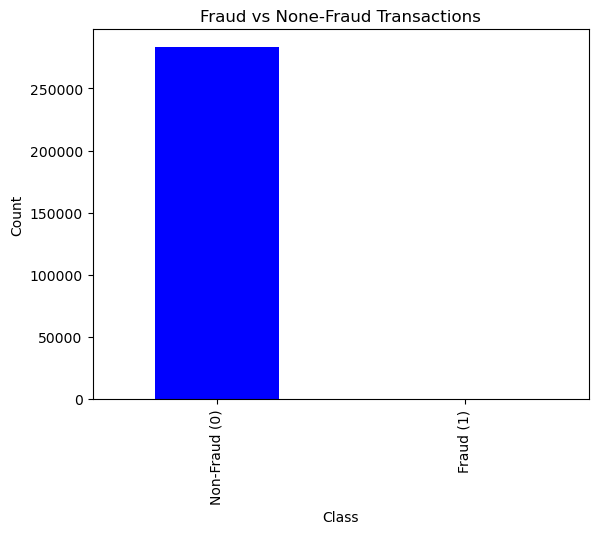

In [16]:
df['Class'].value_counts().plot(kind='bar', color=['blue','red'])
plt.title('Fraud vs None-Fraud Transactions')
plt.xticks(ticks=[0,1], labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.ylabel('Count')
plt.show()

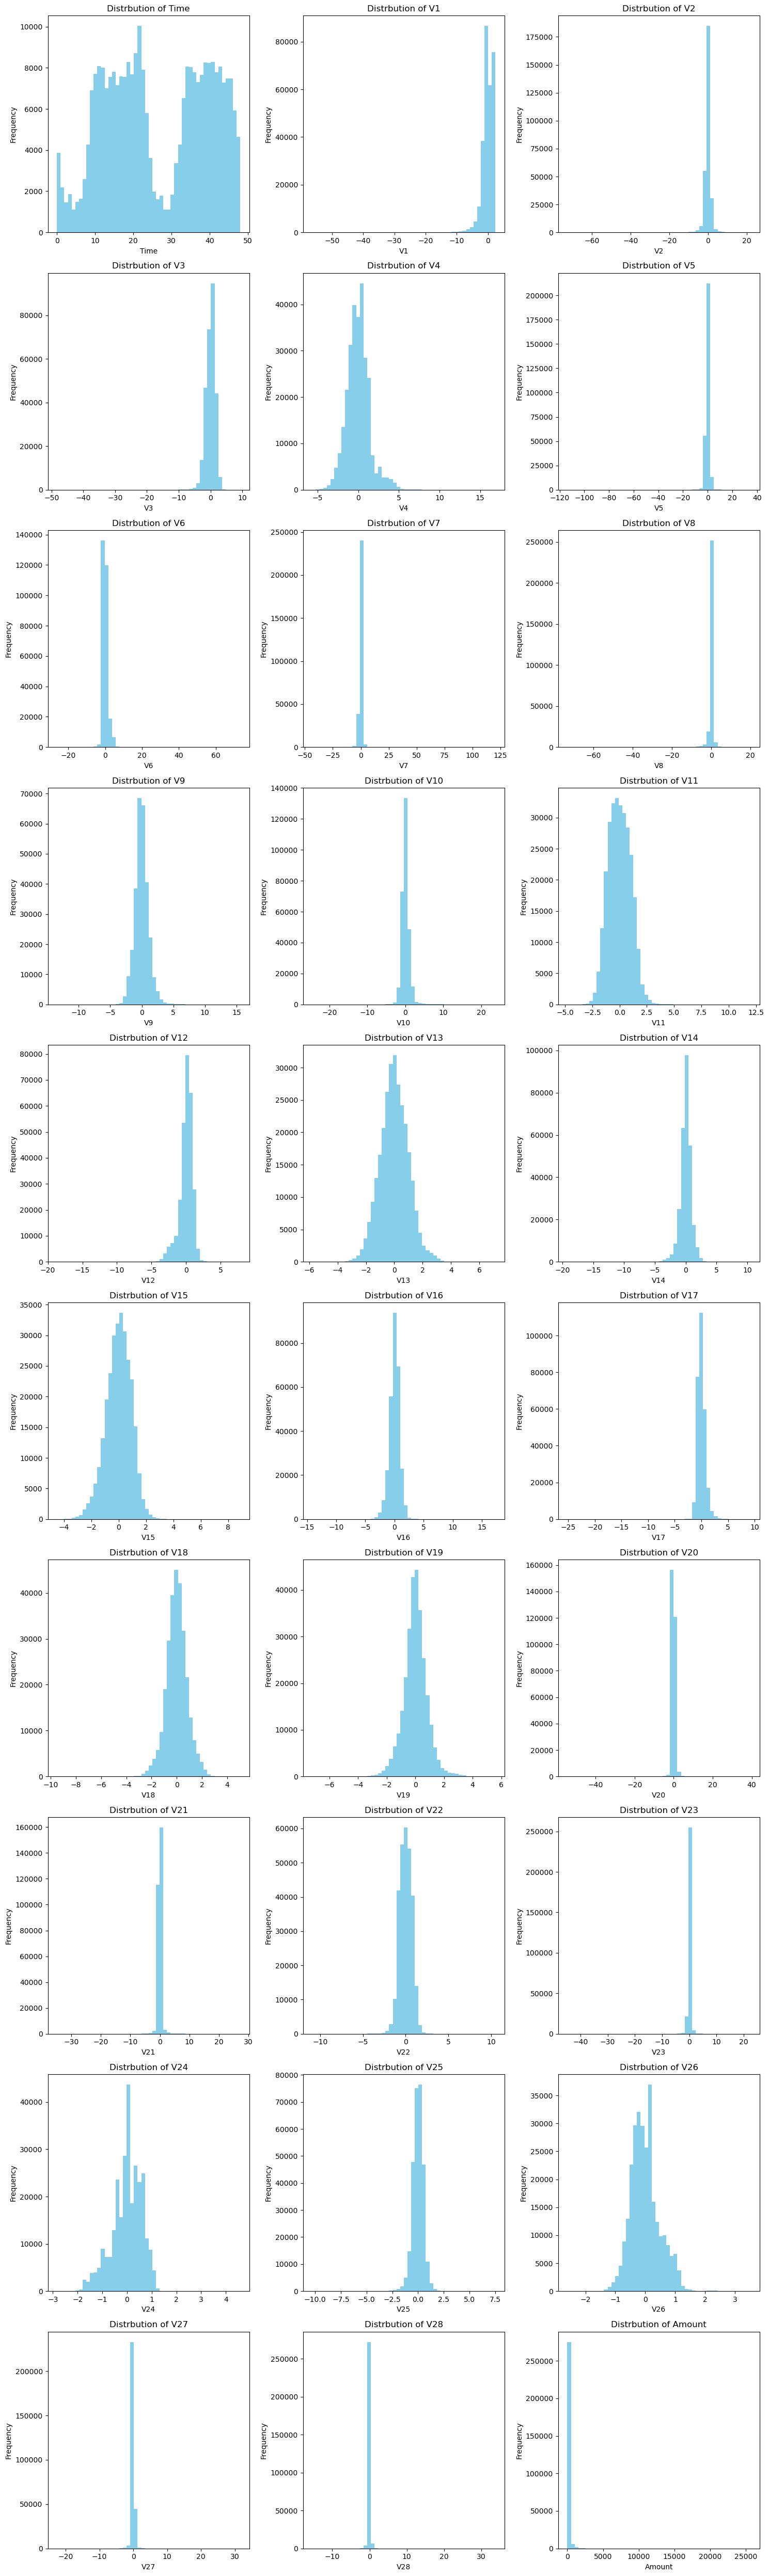

In [17]:
columns = df.select_dtypes(include=['float64','int64']).columns
columns = [col for col in columns if col!='Class']
num_columns = len(columns)


rows = int(np.ceil(num_columns / 3))
cols = 3   
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()
for i, column in enumerate(columns):
    if df[column].nunique() > 1:
        axes[i].hist(df[column], bins=50, color='skyblue')
        axes[i].set_title(f"Distrbution of {column}")
        axes[i].set_xlabel(column)
        axes[i].set_ylabel("Frequency")
    else:
        axes[i].axis('off')

for i in range(num_columns, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

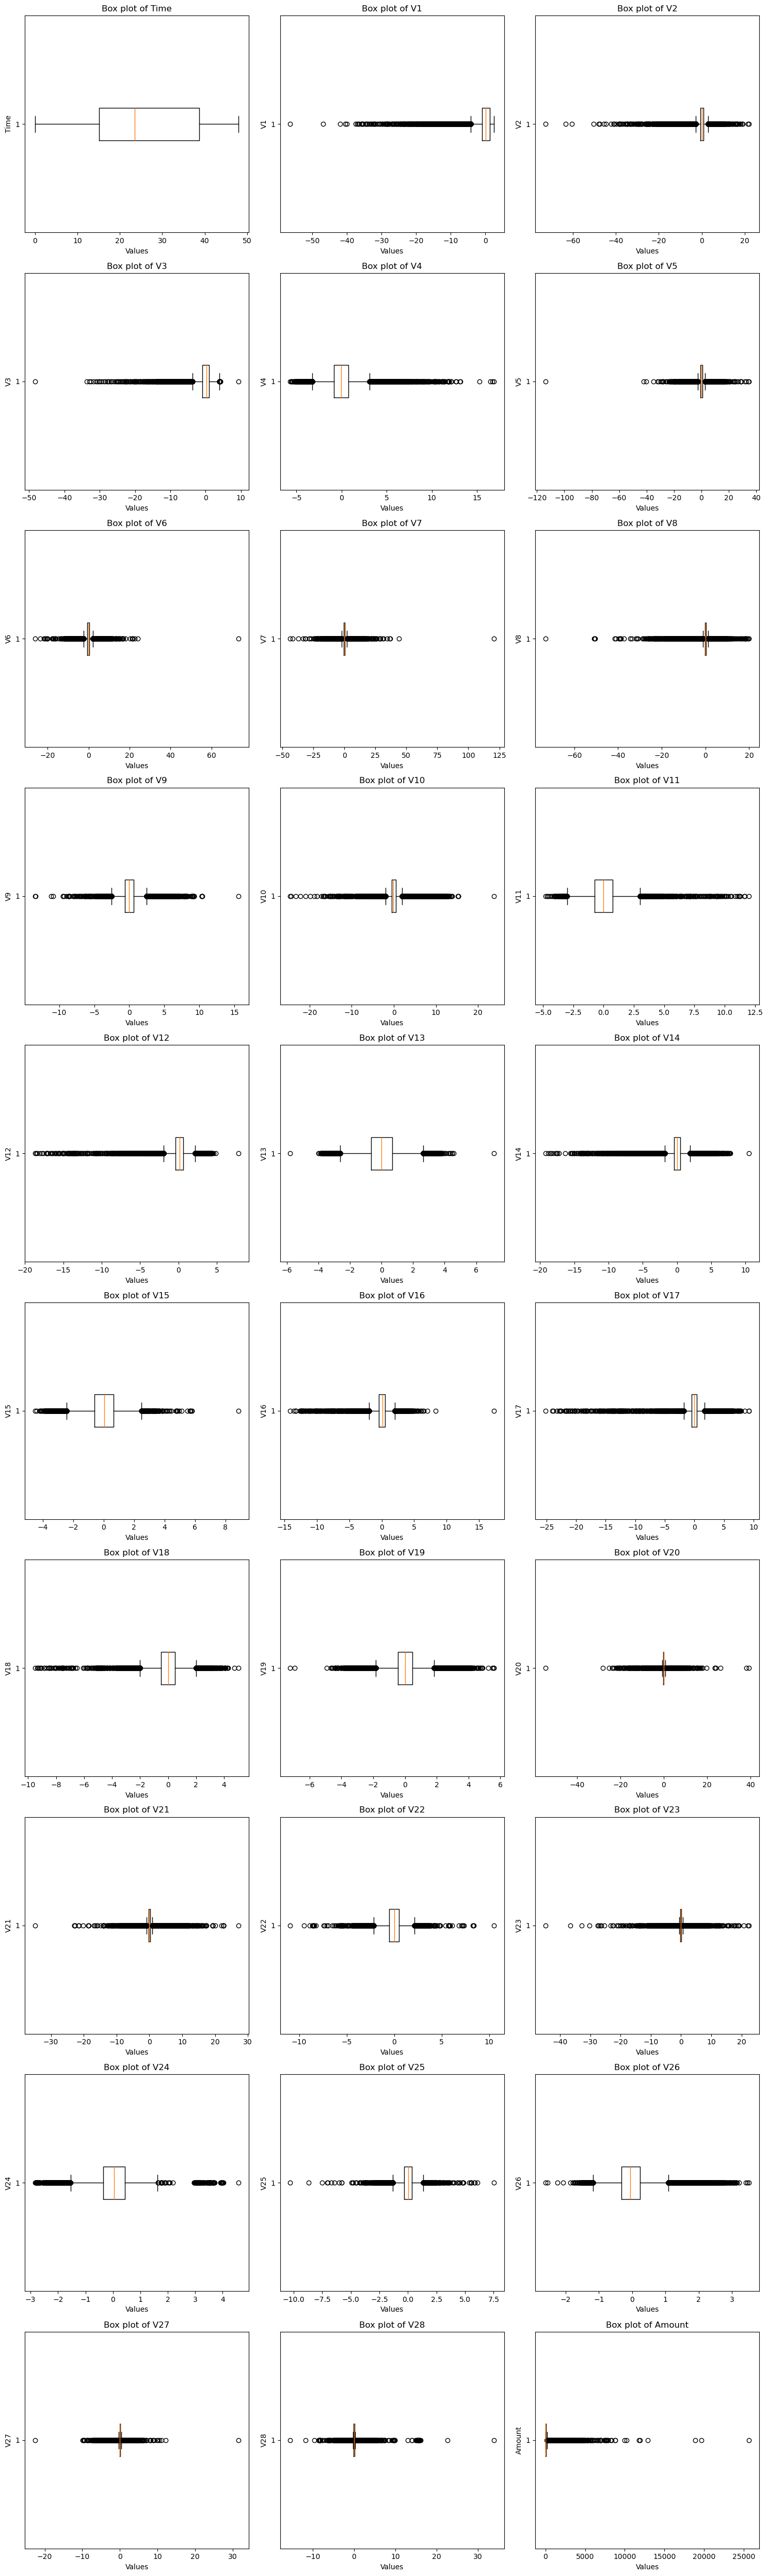

In [18]:
rows = 10
fig_bp, axes_bp = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes_bp = axes_bp.flatten()
for i, column in enumerate(columns):
    if df[column].nunique() > 1:
        axes_bp[i].boxplot(df[column], vert=False)
        axes_bp[i].set_title(f"Box plot of {column}")
        axes_bp[i].set_xlabel("Values")
        axes_bp[i].set_ylabel(column)
    else:
        axes_bp[i].axis('off')

for i in range(num_columns, len(axes_bp)):
    axes_bp[i].axis('off')

plt.tight_layout()
plt.show()

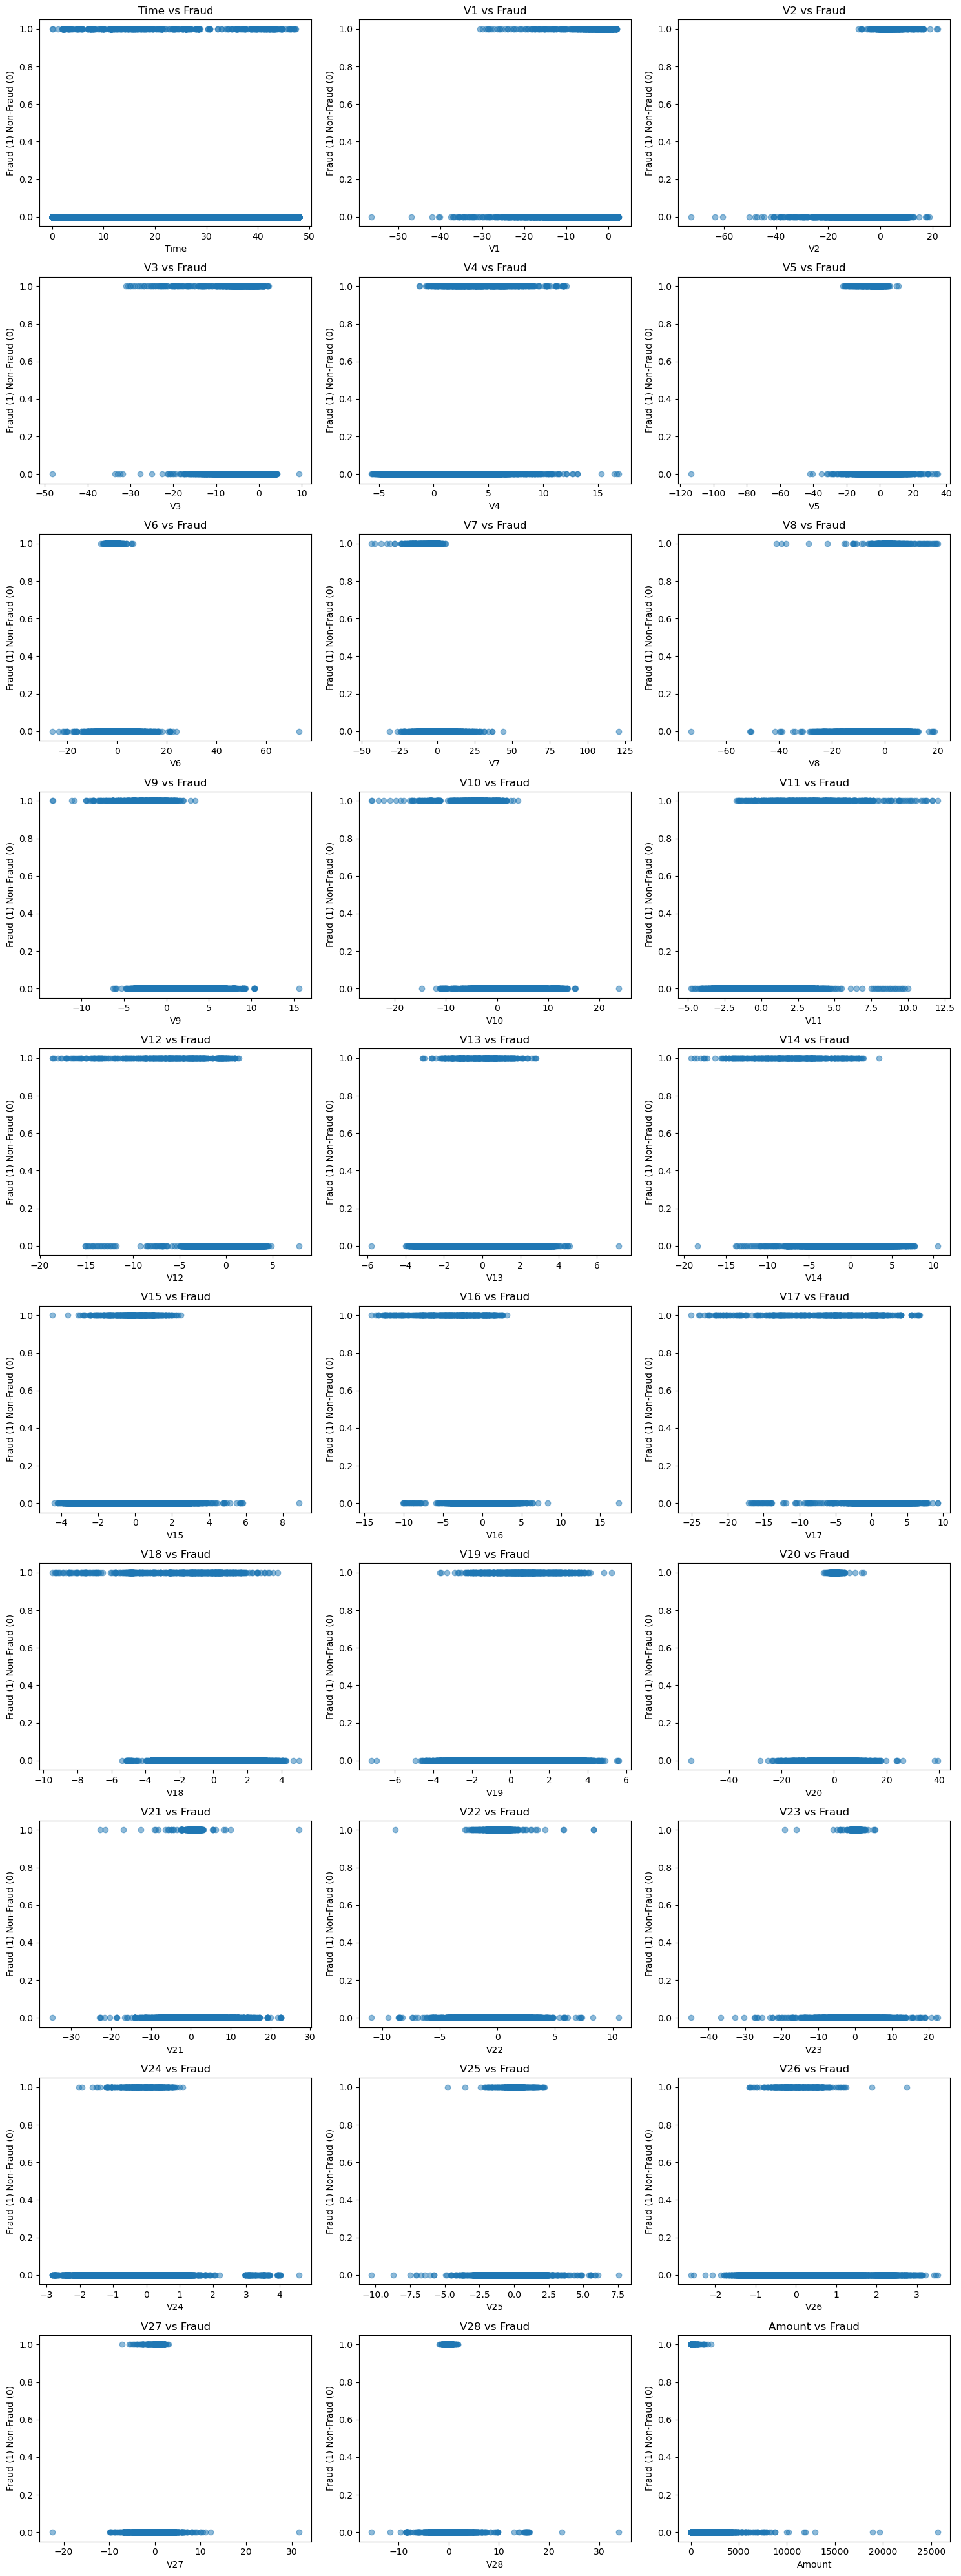

In [19]:
columns = [col for col in columns if col!='Class']
num_columns = len(columns)
fig_scat, axes_scat = plt.subplots(rows, cols, figsize=(15,4*rows))
axes_scat = axes_scat.flatten()
for i, column in enumerate(columns):
    if df[column].nunique() > 1:
        axes_scat[i].scatter(df[column], df['Class'], alpha = 0.5)
        axes_scat[i].set_title(f"{column} vs Fraud")
        axes_scat[i].set_xlabel(column)
        axes_scat[i].set_ylabel("Fraud (1) Non-Fraud (0)")
    else:
        axes_scat[i].axis('off')

for i in range(num_columns, len(axes_scat)):
    axes_scat[i].axis('off')

plt.tight_layout()
plt.show()

In [20]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


In [42]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


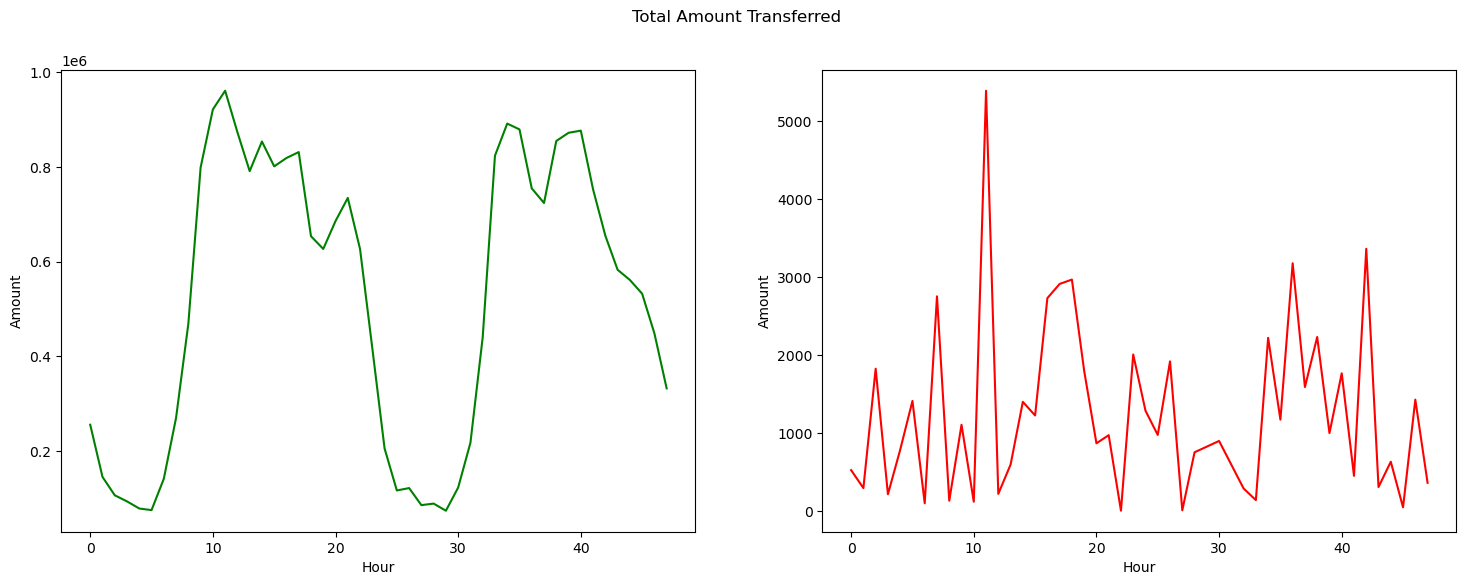

In [43]:
df['Hour'] = df['Time'].apply(lambda x: int(x))
df_grouped = df.groupby(['Hour', 'Class'])['Amount'].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))
sns.lineplot(ax=ax1, data=df_grouped[df_grouped['Class'] == 0], x='Hour', y='Amount', color = 'green')
sns.lineplot(ax=ax2, data=df_grouped[df_grouped['Class'] == 1], x='Hour', y='Amount', color='red')
plt.suptitle("Total Amount Transferred")
plt.show()


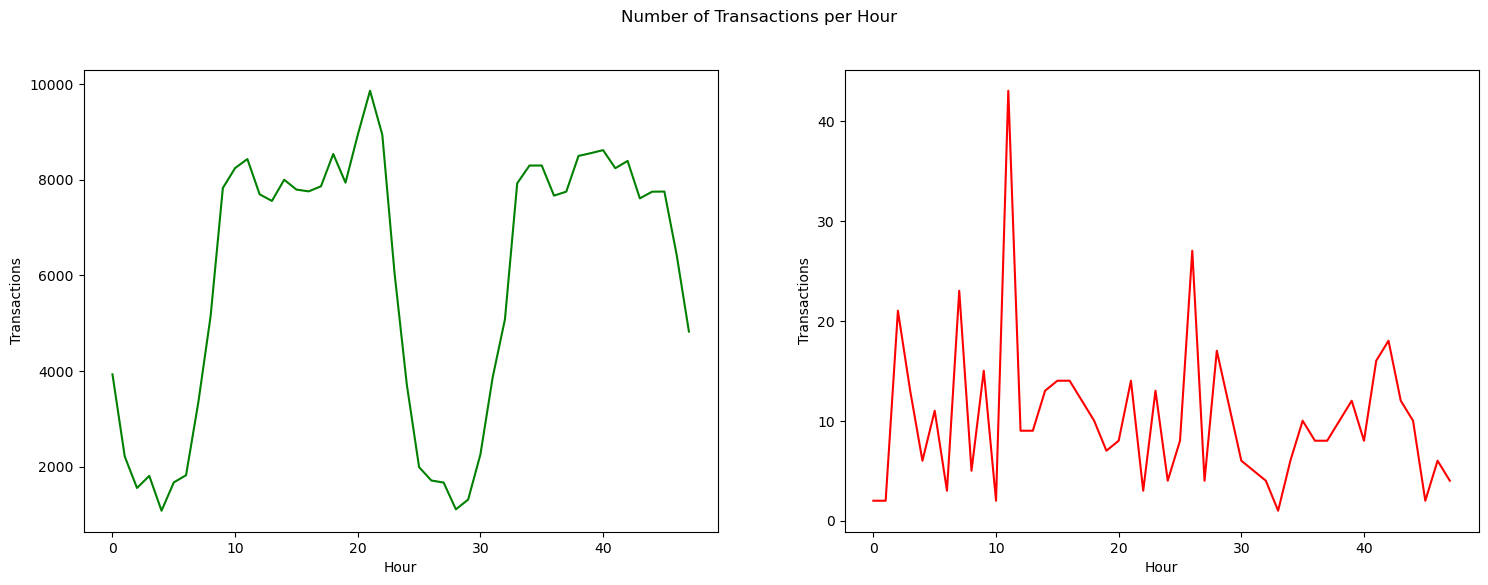

In [45]:
df_grouped = df.groupby(['Hour', 'Class']).size().reset_index(name='Transactions')
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
sns.lineplot(ax=ax1, data=df_grouped[df_grouped['Class'] == 0], x='Hour', y='Transactions', color = "green")
sns.lineplot(ax=ax2, data=df_grouped[df_grouped['Class'] == 1], x='Hour', y='Transactions', color='red')
plt.suptitle("Number of Transactions per Hour")
plt.show()

In [23]:
correlation_matrix = df.corr()
threshold = 0.7
strong_corr = []
for column in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if abs(correlation_matrix.loc[row, column]) >= threshold and row!= column:
            strong_corr.append((row, column, correlation_matrix.loc[row,column]))

if not strong_corr:
    print("No strong correlation between features")
for pair in strong_corr:
    print(f"Features {pair[0]} and {pair[1]} have a correlation of {pair[2]:.2f}")
    
        

No strong correlation between features


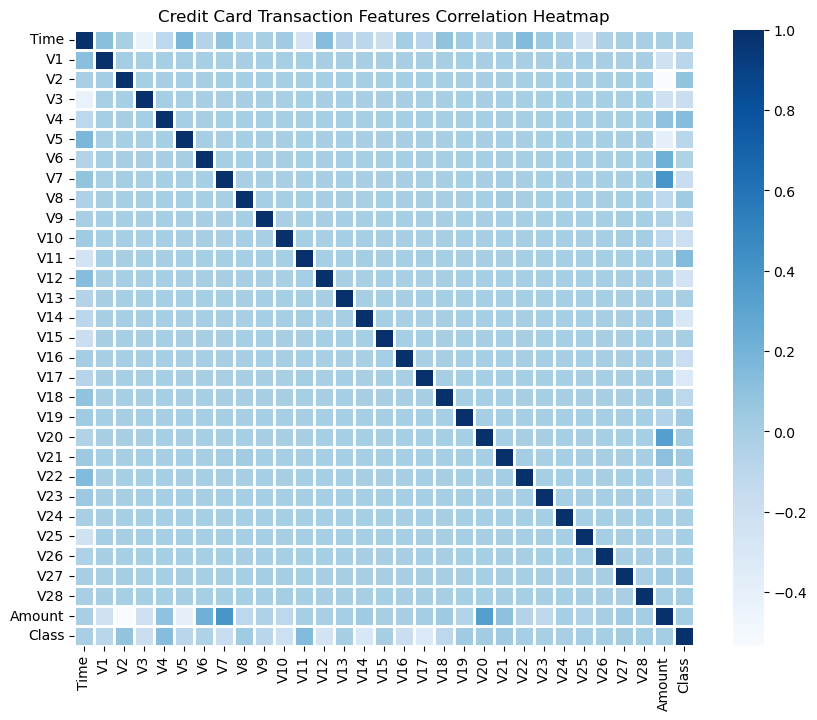

In [233]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, linewidths=1, cmap='Blues')
plt.title('Credit Card Transaction Features Correlation Heatmap')
plt.show()

In [206]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [203]:
X = df.drop('Class', axis=1)
Y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=False)
xgb_test = xgb.DMatrix(X_test, y_test, enable_categorical=False)
xgb_val = xgb.DMatrix(X_val, y_val, enable_categorical=False)

n = 1000
params = {
    'objective': 'binary:logistic',
    'max_depth': 2,
    'learning_rate': 0.0239,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.9,
    'eval_metric': 'auc',
    'scale_pos_weight' :2 * (df['Class'].value_counts()[0] / df['Class'].value_counts()[1])
                             }

watchlist = [(xgb_train, 'train'), (xgb_val, 'validation')]

model = xgb.train(params=params, dtrain=xgb_train, num_boost_round=n,maximize=True, evals=watchlist, early_stopping_rounds=50, verbose_eval=True)

preds = model.predict(xgb_test)
preds = preds.astype(int)

preds_train = model.predict(xgb_train)
preds_train = preds_train.astype(int)

print(confusion_matrix(y_test, preds))

[0]	train-auc:0.94151	validation-auc:0.94905
[1]	train-auc:0.95979	validation-auc:0.96871
[2]	train-auc:0.96015	validation-auc:0.96939
[3]	train-auc:0.96206	validation-auc:0.97085
[4]	train-auc:0.96604	validation-auc:0.96998
[5]	train-auc:0.96619	validation-auc:0.97021
[6]	train-auc:0.96822	validation-auc:0.97082
[7]	train-auc:0.96827	validation-auc:0.97082
[8]	train-auc:0.97172	validation-auc:0.98529
[9]	train-auc:0.97173	validation-auc:0.98533
[10]	train-auc:0.97263	validation-auc:0.98582
[11]	train-auc:0.97502	validation-auc:0.98488
[12]	train-auc:0.98057	validation-auc:0.98560
[13]	train-auc:0.98027	validation-auc:0.98533
[14]	train-auc:0.98055	validation-auc:0.98505
[15]	train-auc:0.98062	validation-auc:0.98497
[16]	train-auc:0.98088	validation-auc:0.98486
[17]	train-auc:0.98040	validation-auc:0.98488
[18]	train-auc:0.98147	validation-auc:0.98373
[19]	train-auc:0.98151	validation-auc:0.98372
[20]	train-auc:0.98089	validation-auc:0.98501
[21]	train-auc:0.98125	validation-auc:0.9841

In [204]:
print(classification_report(y_test, preds, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.00      0.00      0.00        90

    accuracy                           1.00     56746
   macro avg       0.50      0.50      0.50     56746
weighted avg       1.00      1.00      1.00     56746



In [205]:
roc_auc_score(y_test, preds)

0.5

In [291]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=40, random_state=42, class_weight='balanced', max_depth=7)
model.fit(X_train, y_train)
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [292]:
print(confusion_matrix(y_train, train_predictions))

[[226489    108]
 [    26    357]]


In [293]:
print(confusion_matrix(y_test, test_predictions))

[[56623    33]
 [   17    73]]


In [294]:
print(classification_report(y_train, train_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226597
           1       0.77      0.93      0.84       383

    accuracy                           1.00    226980
   macro avg       0.88      0.97      0.92    226980
weighted avg       1.00      1.00      1.00    226980



In [295]:
print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.69      0.81      0.74        90

    accuracy                           1.00     56746
   macro avg       0.84      0.91      0.87     56746
weighted avg       1.00      1.00      1.00     56746



In [296]:
roc_auc_score(y_train, train_predictions)

0.9658191327143156

In [297]:
roc_auc_score(y_test, test_predictions)

0.9052643242649596